# Object-Finder — Comparaison d'Architectures CNN
## Classification d'Âge — FairFace Dataset

---

> **Projet** : Pipeline YOLO + CNN pour l'aide à la navigation des personnes malvoyantes
> **Auteur** : Mohamed Khalil Khelifi — 4ème année Data Science & IA, École Polytechnique de Sousse
> **Module** : Deep Learning

---

## Objectif de ce notebook

Comparer **4 architectures CNN** sur le même dataset (FairFace) dans les mêmes conditions
pour justifier scientifiquement le choix final du modèle.

| Étape | Architecture | Stratégie |
|-------|-------------|-----------|
| 1 | **CNN Simple** (from scratch) | Baseline — sans Transfer Learning |
| 2 | **MobileNetV2** | Transfer Learning léger |
| 3 | **ResNet18** | Transfer Learning classique |
| 4 | **EfficientNet-B0** | Transfer Learning optimal |
| 5 | **Fine-tuning EfficientNet-B0** | Modèle final poussé à son maximum |


## 0 — Installation & Imports

In [1]:
# Installation des dépendances
!pip install -q torchmetrics pytorch_lightning

In [24]:
import warnings
warnings.filterwarnings('ignore')

import os
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from IPython.display import clear_output

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader , WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image

import torchmetrics
import pytorch_lightning as pl
from pytorch_lightning.callbacks import Callback, EarlyStopping, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report

# ── Reproductibilité ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Style graphiques ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 110,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.size'         : 11
})

# ── Détection accélérateur ───────────────────────────────────────────────────
accelerator = 'cpu'
if torch.backends.mps.is_available(): accelerator = 'mps'
if torch.cuda.is_available():         accelerator = 'gpu'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Imports OK')
print(f'Accélérateur : {accelerator}')
if torch.cuda.is_available():
    print(f'   GPU          : {torch.cuda.get_device_name(0)}')

Imports OK
Accélérateur : gpu
   GPU          : Tesla T4


## 1 — Chargement des Données

Les données ont été préparées dans `2_Preprocessing.ipynb` :
mapping âge → classe, vérification, et sauvegarde en CSV.
On charge directement le résultat ici.

In [3]:
# ── Charger les CSV produits par 2_Preprocessing ─────────────────────────────
train_df = pd.read_csv("/kaggle/input/notebooks/medkhalilkh/2-preprocessing/train.csv")
val_df   = pd.read_csv("/kaggle/input/notebooks/medkhalilkh/2-preprocessing/val.csv")

print(f"Données chargées")
print(f"Train : {len(train_df):,} images")
print(f"Val   : {len(val_df):,} images")
print(f"Colonnes : {list(train_df.columns)}")
print()
print(train_df.head(3))

Données chargées
Train : 86,744 images
Val   : 10,954 images
Colonnes : ['chemin', 'classe']

                                              chemin         classe
0  /kaggle/input/datasets/aibloy/fairface/FairFac...  personne_agee
1  /kaggle/input/datasets/aibloy/fairface/FairFac...         adulte
2  /kaggle/input/datasets/aibloy/fairface/FairFac...         enfant


## 2 — FairFaceDataset & DataLoaders

### Pipeline Deep Learning

```
Image (chemin)
    ↓ PIL.open → RGB
    ↓ Resize 224×224       (format attendu par tous les modèles pré-entraînés)
    ↓ Augmentation (train) → flip, rotation, colorjitter, random erasing
    ↓ ToTensor
    ↓ Normalize             → mean/std ImageNet standard
    ↓ Tensor [3, 224, 224]
```

> Ce DataLoader est **partagé entre les 4 modèles** — condition essentielle
> pour une comparaison équitable.

In [4]:
#Classes
CLASS_TO_IDX = {"adulte": 0, "enfant": 1, "personne_agee": 2}
IDX_TO_CLASS = {0: "adulte", 1: "enfant", 2: "personne_agée"}
CLASS_NAMES  = ["adulte", "enfant", "personne_agée"]
NUM_CLASSES  = 3

#Dataset personnalisé
class FairFaceDataset(Dataset):
    """Charge les images FairFace à la volée depuis les chemins CSV."""
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row["chemin"]).convert("RGB")
        label = CLASS_TO_IDX[row["classe"]]
        if self.transform:
            image = self.transform(image)
        return image, label

# Transformations
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2))
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

#DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(
    FairFaceDataset(train_df, train_transform),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    FairFaceDataset(val_df, val_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

print(f"DataLoaders créés")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Batches train : {len(train_loader):,}")
print(f"Batches val   : {len(val_loader):,}")
print(f"Shape batch   : {next(iter(val_loader))[0].shape}")


DataLoaders créés
Batch size    : 32
Batches train : 2,711
Batches val   : 343
Shape batch   : torch.Size([32, 3, 224, 224])


## 3 — Infrastructure d'Entraînement

### Callbacks PyTorch Lightning

On reprend exactement la structure des TPs du cours :
- **`LivePlot`** : visualise les courbes loss/accuracy en temps réel après chaque époque
- **`EarlyStopping`** : arrête l'entraînement si val_loss ne s'améliore plus (patience=5)
- **`ModelCheckpoint`** : sauvegarde le meilleur modèle automatiquement

### Classe de base `LightningModule`

boucle d'entraînement commune héritée par tous les modèles.

In [5]:
# ── LivePlot Callback ────────────────────────────────────────────────────────
class LivePlot(Callback):
    """Visualise loss/accuracy après chaque époque."""

    def __init__(self, title='Training'):
        self.title      = title
        self.train_loss, self.val_loss = [], []
        self.train_acc,  self.val_acc  = [], []

    def on_train_epoch_end(self, trainer, pl_module):
        logs = trainer.callback_metrics
        self.train_loss.append(float(logs.get('train_loss_epoch', logs.get('train_loss', 0))))
        self.train_acc.append( float(logs.get('train_acc_epoch',  logs.get('train_acc',  0))))

    def on_validation_epoch_end(self, trainer, pl_module):
        logs = trainer.callback_metrics
        self.val_loss.append(float(logs.get('val_loss', 0)))
        self.val_acc.append( float(logs.get('val_acc',  0)))

        if len(self.train_loss) == 0:
            return

        n = min(len(self.train_loss), len(self.val_loss))
        e = range(1, n + 1)

        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
        fig.suptitle(self.title, fontsize=13, fontweight='bold')

        ax1.plot(e, self.train_loss[:n], label='Train', lw=2, color='steelblue')
        ax1.plot(e, self.val_loss[:n],   label='Val',   lw=2, color='tomato', ls='--')
        ax1.set(title='Loss (Cross-Entropy)', xlabel='Époque', ylabel='Loss')
        ax1.legend(); ax1.grid(True, alpha=0.3)

        ax2.plot(e, [a*100 for a in self.train_acc[:n]], label='Train', lw=2, color='steelblue')
        ax2.plot(e, [a*100 for a in self.val_acc[:n]],   label='Val',   lw=2, color='tomato', ls='--')
        ax2.set(title='Accuracy (%)', xlabel='Époque', ylabel='Accuracy (%)')
        ax2.legend(); ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

print('LivePlot défini')

LivePlot défini


In [6]:
#Classe de base LightningModule
class CNNBase(pl.LightningModule):
    """
    Classe de base partagée par les 4 architectures.
    Même boucle train/val, même loss, mêmes métriques.
    Chaque sous-classe définit son propre forward().
    """
    def __init__(self, lr: float = 1e-3, label_smoothing: float = 0.01):
        super().__init__()
        self.lr            = lr
        self.criterion     = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        self.train_acc_metric = torchmetrics.Accuracy(task='multiclass', num_classes=NUM_CLASSES)
        self.val_acc_metric   = torchmetrics.Accuracy(task='multiclass', num_classes=NUM_CLASSES)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        logits = self(images)
        loss   = self.criterion(logits, labels)
        preds  = torch.argmax(logits, dim=1)
        self.log('train_loss', loss,                                on_epoch=True, prog_bar=True, sync_dist=True)
        self.log('train_acc',  self.train_acc_metric(preds, labels), on_epoch=True, prog_bar=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        logits = self(images)
        loss   = self.criterion(logits, labels)
        preds  = torch.argmax(logits, dim=1)
        self.log('val_loss', loss,                              on_epoch=True, prog_bar=True, sync_dist=True)
        self.log('val_acc',  self.val_acc_metric(preds, labels), on_epoch=True, prog_bar=True, sync_dist=True)

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.lr, weight_decay=1e-4)

print('CNNBase (LightningModule) défini')

CNNBase (LightningModule) défini


## 4 — Comparaison des 4 Architectures

### Protocole expérimental

Pour garantir une comparaison **équitable et reproductible** :

| Paramètre | Valeur |
|-----------|--------|
| Dataset | FairFace (train/val identiques) |
| Epochs comparaison | **10**  |
| Batch size | 32 |
| Optimizer | Adam (lr=1e-3) |
| Loss | CrossEntropyLoss (label_smoothing=0.01) |
| Seed | 42 |
---

### 4.1 Modèle 1 — CNN Simple (Baseline, from scratch)

**Pourquoi commencer par un CNN simple ?**

Avant d'utiliser le Transfer Learning, on doit établir une **baseline** —
un point de référence qui montre les performances sans pré-entraînement.

**Architecture :**
```
Input (224×224×3)
    ↓ Conv2d(3→32, 3×3) + BatchNorm + ReLU + MaxPool
    ↓ Conv2d(32→64, 3×3) + BatchNorm + ReLU + MaxPool
    ↓ Conv2d(64→128, 3×3) + BatchNorm + ReLU + MaxPool
    ↓ AdaptiveAvgPool → Flatten
    ↓ Linear(128→256) + ReLU + Dropout(0.4)
    ↓ Linear(256→3)  [logits]
```

In [9]:
class SimpleCNN(CNNBase):
    """CNN 3 blocs Conv entraîné from scratch. Sert de baseline."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.pool       = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))

# ── Paramètres calculés dynamiquement ────────────────────────────────────────
_tmp = SimpleCNN()
simple_params  = sum(p.numel() for p in _tmp.parameters())
simple_size_mb = sum(p.numel() * p.element_size() for p in _tmp.parameters()) / (1024**2)
del _tmp
print(f"CNN Simple — Paramètres : {simple_params:,}  |  Taille : {simple_size_mb:.1f} MB")


CNN Simple — Paramètres : 127,491  |  Taille : 0.5 MB


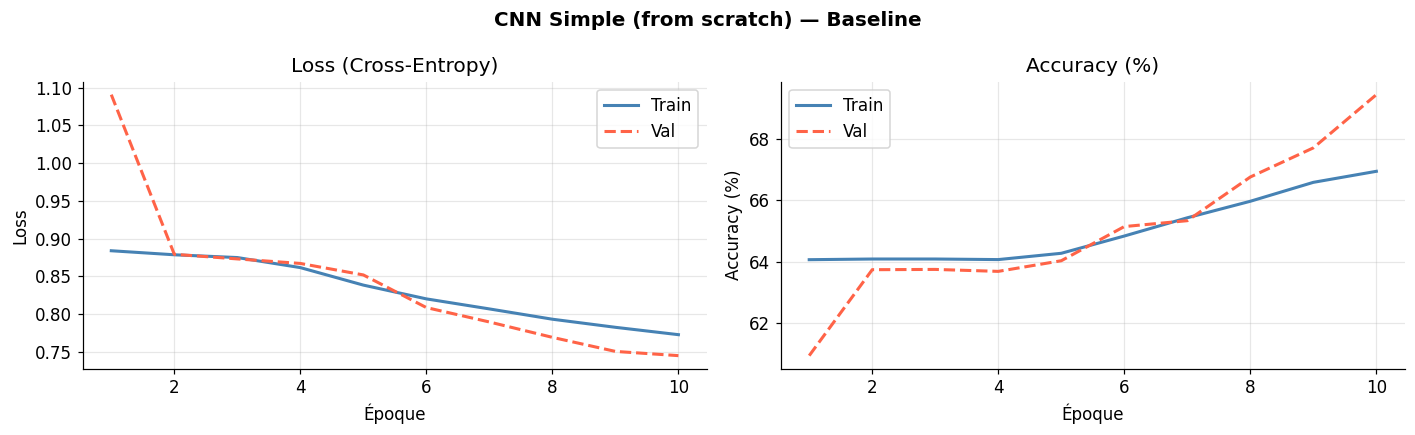


  CNN Simple — Résultats
  Val Accuracy : 69.05%


NameError: name 'elapsed_simple' is not defined

In [10]:
# ── Entraînement CNN Simple
EPOCHS_COMPARE = 10

plot_simple = LivePlot(title='CNN Simple (from scratch) — Baseline')
model_simple = SimpleCNN(lr=1e-3)

trainer_simple = pl.Trainer(
    max_epochs = EPOCHS_COMPARE,
    accelerator = accelerator,
    callbacks = [plot_simple,EarlyStopping(monitor='val_loss', patience=5, mode='min')],
    enable_progress_bar = False,
    logger              = False,
)

start = time.time()
trainer_simple.fit(model_simple, train_loader, val_loader)
elapsed = time.time() - start

acc_simple = trainer_simple.validate(model_simple, val_loader, verbose=False)[0]['val_acc']

print(f"\n{'='*50}")
print(f"  CNN Simple — Résultats")
print(f"  Val Accuracy : {acc_simple*100:.2f}%")
print(f"  Durée        : {elapsed/60:.1f} min")
print(f"{'='*50}")

---
### 4.2 Modèle 2 — MobileNetV2 (Transfer Learning léger)

**Pourquoi MobileNetV2 ?**

MobileNetV2 est conçu pour les **systèmes embarqués et temps réel** — léger (14 MB)
et rapide. Il a été pré-entraîné sur ImageNet (1.4M images, 1000 classes).

Le Transfer Learning fonctionne comme un expert qui a déjà lu 1.4 million d'images —
on lui demande juste d'apprendre 3 nouvelles classes.

**Stratégie : fine-tuning 2 phases**
1. Phase 1 — seule la tête classifier est entraînée (backbone gelé)
2. Phase 2 — toutes les couches dégelées avec learning rates différenciés

```
ImageNet weights (gelés)
        ↓
  MobileNetV2 features
        ↓
  [nouvelle tête] Linear(1280 → 3)  ← seule partie entraînable
```


In [11]:
class MobileNetV2Model(CNNBase):
    """MobileNetV2 pré-entraîné ImageNet. Backbone gelé, tête remplacée."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        backbone = models.mobilenet_v2(weights='IMAGENET1K_V1')
        for param in backbone.parameters():
            param.requires_grad = False
        backbone.classifier[1] = nn.Linear(1280, NUM_CLASSES)
        self.model = backbone

    def forward(self, x):
        return self.model(x)

# ── Paramètres calculés dynamiquement ────────────────────────────────────────
_tmp = MobileNetV2Model()
mv2_params_total     = sum(p.numel() for p in _tmp.parameters())
mv2_params_trainable = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
mv2_size_mb          = sum(p.numel() * p.element_size() for p in _tmp.parameters()) / (1024**2)
del _tmp
print(f"MobileNetV2 — Paramètres totaux      : {mv2_params_total:,}")
print(f"MobileNetV2 — Paramètres entraînables: {mv2_params_trainable:,}  (tête seulement)")
print(f"MobileNetV2 — Taille                 : {mv2_size_mb:.1f} MB")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 117MB/s] 

MobileNetV2 — Paramètres totaux      : 2,227,715
MobileNetV2 — Paramètres entraînables: 3,843  (tête seulement)
MobileNetV2 — Taille                 : 8.5 MB


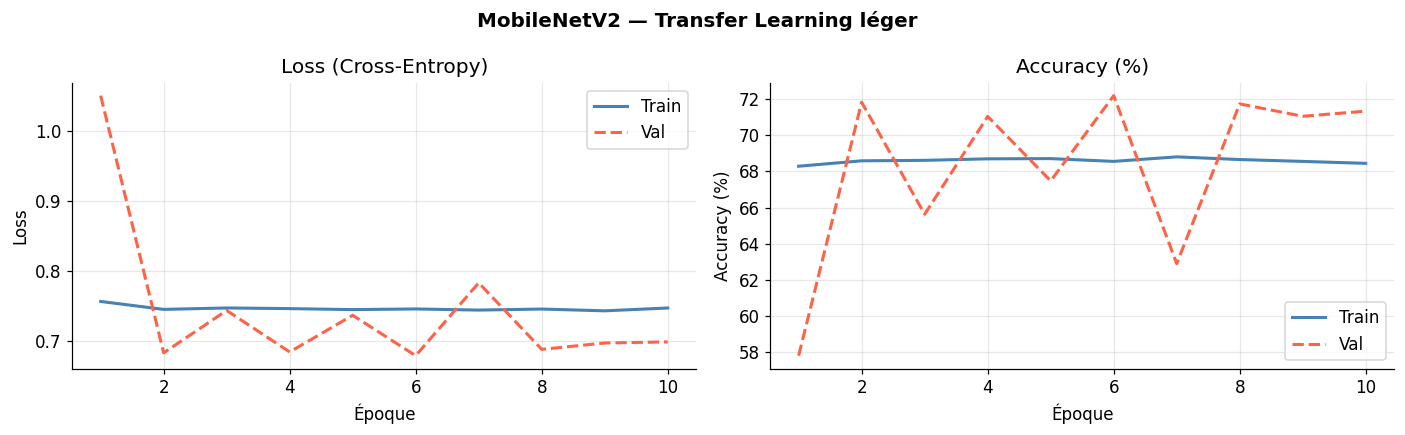


  MobileNetV2 — Résultats
  Val Accuracy : 71.96%
  Durée        : 67.5 min


In [12]:
# ── Entraînement MobileNetV2 ─────────────────────────────────────────────────
plot_mv2  = LivePlot('MobileNetV2 — Transfer Learning léger')
model_mv2 = MobileNetV2Model(lr=1e-3)

trainer_mv2 = pl.Trainer(
    max_epochs          = EPOCHS_COMPARE,
    accelerator         = accelerator,
    callbacks           = [plot_mv2,
                           EarlyStopping(monitor='val_loss', patience=5, mode='min')],
    enable_progress_bar = False,
    logger              = False,
)

t0 = time.time()
trainer_mv2.fit(model_mv2, train_loader, val_loader)
elapsed_mv2 = time.time() - t0

acc_mv2 = trainer_mv2.validate(model_mv2, val_loader, verbose=False)[0]['val_acc']

print(f"\n{'='*50}")
print(f"  MobileNetV2 — Résultats")
print(f"  Val Accuracy : {acc_mv2*100:.2f}%")
print(f"  Durée        : {elapsed_mv2/60:.1f} min")
print(f"{'='*50}")

---
### 4.3 Modèle 3 — ResNet18 (Transfer Learning classique)

**Pourquoi ResNet18 ?**

ResNet introduit les **connexions résiduelles** (skip connections) qui résolvent
le problème du gradient vanishing dans les réseaux profonds.
Il est plus lourd que MobileNetV2 mais plus précis sur des tâches complexes.

```
Bloc résiduel ResNet :
Input ──┐
   ↓    │
Conv2d  │
BN+ReLU │
Conv2d  │
   ↓    │
  Add ←─┘  ← Skip connection
  ReLU
```

In [13]:
class ResNet18Model(CNNBase):
    """ResNet18 pré-entraîné ImageNet. Skip connections contre gradient vanishing."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        backbone = models.resnet18(weights='IMAGENET1K_V1')
        for param in backbone.parameters():
            param.requires_grad = False
        backbone.fc = nn.Linear(512, NUM_CLASSES)
        self.model  = backbone

    def forward(self, x):
        return self.model(x)

# ── Paramètres calculés dynamiquement ────────────────────────────────────────
_tmp = ResNet18Model()
rn_params_total     = sum(p.numel() for p in _tmp.parameters())
rn_params_trainable = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
rn_size_mb          = sum(p.numel() * p.element_size() for p in _tmp.parameters()) / (1024**2)
del _tmp
print(f"ResNet18 — Paramètres totaux      : {rn_params_total:,}")
print(f"ResNet18 — Paramètres entraînables: {rn_params_trainable:,}  (tête seulement)")
print(f"ResNet18 — Taille                 : {rn_size_mb:.1f} MB")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


ResNet18 — Paramètres totaux      : 11,178,051
ResNet18 — Paramètres entraînables: 1,539  (tête seulement)
ResNet18 — Taille                 : 42.6 MB


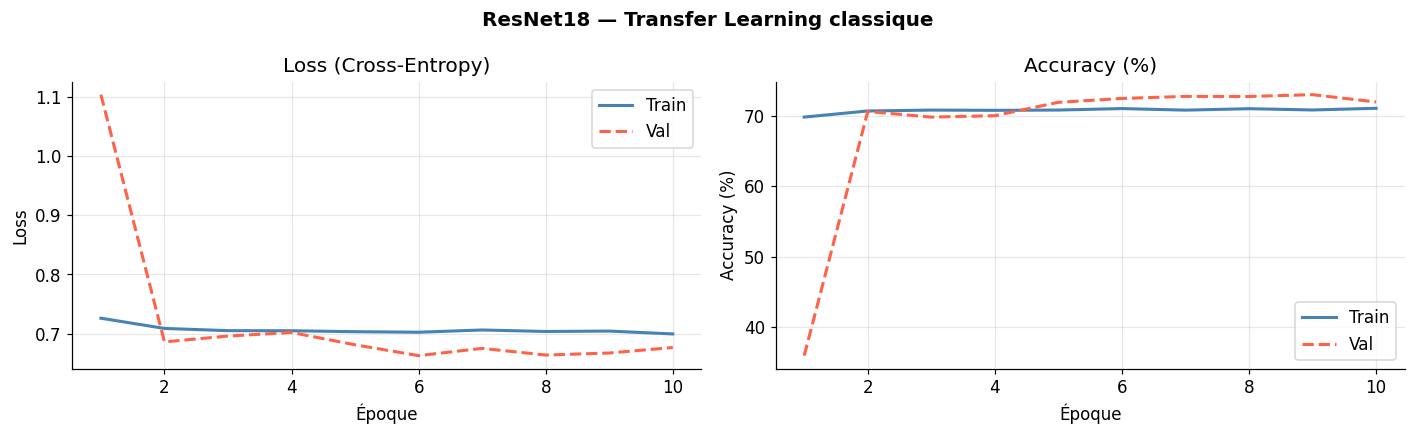


  ResNet18 — Résultats
  Val Accuracy : 69.07%
  Durée        : 64.7 min


In [14]:
# ── Entraînement ResNet18 ────────────────────────────────────────────────────
plot_rn  = LivePlot('ResNet18 — Transfer Learning classique')
model_rn = ResNet18Model(lr=1e-3)

trainer_rn = pl.Trainer(
    max_epochs          = EPOCHS_COMPARE,
    accelerator         = accelerator,
    callbacks           = [plot_rn,
                           EarlyStopping(monitor='val_loss', patience=5, mode='min')],
    enable_progress_bar = False,
    logger              = False,
)

t0 = time.time()
trainer_rn.fit(model_rn, train_loader, val_loader)
elapsed_rn = time.time() - t0

acc_rn = trainer_rn.validate(model_rn, val_loader, verbose=False)[0]['val_acc']

print(f"\n{'='*50}")
print(f"  ResNet18 — Résultats")
print(f"  Val Accuracy : {acc_rn*100:.2f}%")
print(f"  Durée        : {elapsed_rn/60:.1f} min")
print(f"{'='*50}")

---
### 4.4 Modèle 4 — EfficientNet-B0 (Transfer Learning optimal)

**Pourquoi EfficientNet-B0 ?**

EfficientNet est conçu sur le principe de **compound scaling** —
il scale simultanément la profondeur, la largeur et la résolution du réseau
de manière optimale, contrairement aux approches naïves.

In [16]:
class EfficientNetB0Model(CNNBase):
    """EfficientNet-B0 pré-entraîné ImageNet. Compound scaling optimal."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        backbone = models.efficientnet_b0(weights='IMAGENET1K_V1')
        for param in backbone.parameters():
            param.requires_grad = False
        backbone.classifier[1] = nn.Linear(1280, NUM_CLASSES)
        self.model = backbone

    def forward(self, x):
        return self.model(x)

# ── Paramètres calculés dynamiquement ────────────────────────────────────────
_tmp = EfficientNetB0Model()
eff_params_total     = sum(p.numel() for p in _tmp.parameters())
eff_params_trainable = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
eff_size_mb          = sum(p.numel() * p.element_size() for p in _tmp.parameters()) / (1024**2)
del _tmp
print(f"EfficientNet-B0 — Paramètres totaux      : {eff_params_total:,}")
print(f"EfficientNet-B0 — Paramètres entraînables: {eff_params_trainable:,}  (tête seulement)")
print(f"EfficientNet-B0 — Taille                 : {eff_size_mb:.1f} MB")

EfficientNet-B0 — Paramètres totaux      : 4,011,391
EfficientNet-B0 — Paramètres entraînables: 3,843  (tête seulement)
EfficientNet-B0 — Taille                 : 15.3 MB


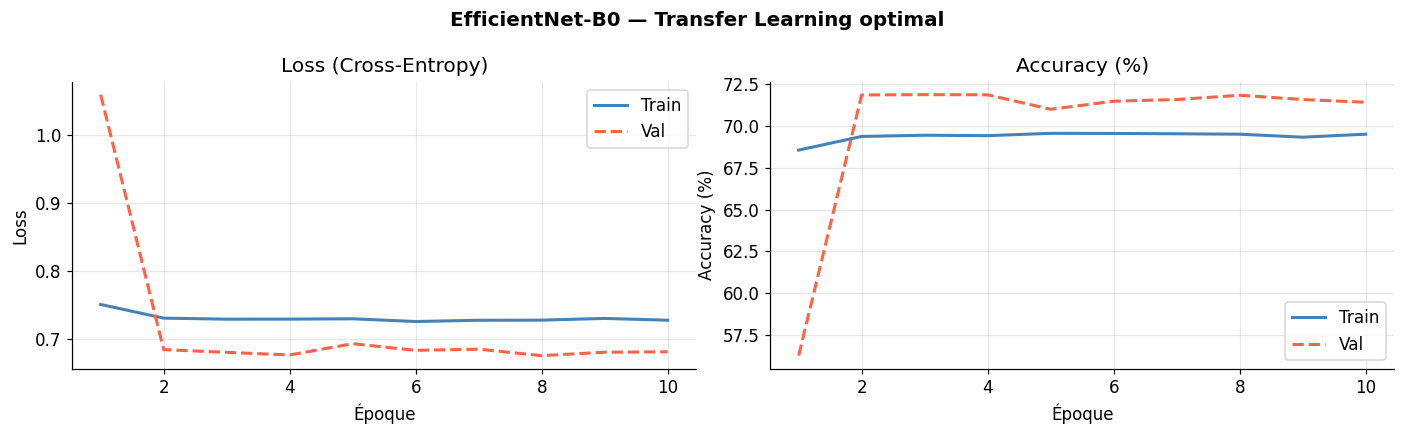


  EfficientNet-B0 — Résultats
  Val Accuracy : 71.60%
  Durée        : 64.8 min


In [18]:
# ── Entraînement EfficientNet-B0 ─────────────────────────────────────────────
plot_eff  = LivePlot('EfficientNet-B0 — Transfer Learning optimal')
model_eff = EfficientNetB0Model(lr=1e-3)

trainer_eff = pl.Trainer(
    max_epochs          = EPOCHS_COMPARE,
    accelerator         = accelerator,
    callbacks           = [plot_eff,
                           EarlyStopping(monitor='val_loss', patience=5, mode='min')],
    enable_progress_bar = False,
    logger              = False,
)

t0 = time.time()
trainer_eff.fit(model_eff, train_loader, val_loader)
elapsed_eff = time.time() - t0

acc_eff = trainer_eff.validate(model_eff, val_loader, verbose=False)[0]['val_acc']

print(f"\n{'='*50}")
print(f"  EfficientNet-B0 — Résultats")
print(f"  Val Accuracy : {acc_eff*100:.2f}%")
print(f"  Durée        : {elapsed_eff/60:.1f} min")
print(f"{'='*50}")

## 5 — Tableau Comparatif & Analyse

Synthèse visuelle des 4 architectures testées dans les mêmes conditions.

In [20]:
# Résultats
results = {
    'CNN Simple'     : {'acc': acc_simple, 'params': simple_params,       'size_mb': simple_size_mb,  'strategy': 'From Scratch'},
    'MobileNetV2'    : {'acc': acc_mv2,    'params': mv2_params_total,     'size_mb': mv2_size_mb,     'strategy': 'Transfer Learning'},
    'ResNet18'       : {'acc': acc_rn,     'params': rn_params_total,      'size_mb': rn_size_mb,      'strategy': 'Transfer Learning'},
    'EfficientNet-B0': {'acc': acc_eff,    'params': eff_params_total,     'size_mb': eff_size_mb,     'strategy': 'Transfer Learning'},
}

best_model = max(results, key=lambda k: results[k]['acc'])

#Tableau texte
print(f"{'='*72}")
print(f"  {'Modèle':<20} {'Val Acc':>10} {'Params':>13} {'Taille':>9}   Stratégie")
print(f"{'='*72}")
for name, r in results.items():
    tag = ' WINNER' if name == best_model else ''
    print(f"  {name:<20} {r['acc']*100:>9.2f}%  {r['params']:>13,}  {r['size_mb']:>7.1f} MB   {r['strategy']}{tag}")
print(f"{'='*72}")

  Modèle                  Val Acc        Params    Taille   Stratégie
  CNN Simple               69.05%        127,491      0.5 MB   From Scratch
  MobileNetV2              71.96%      2,227,715      8.5 MB   Transfer Learning WINNER
  ResNet18                 69.07%     11,178,051     42.6 MB   Transfer Learning
  EfficientNet-B0          71.60%      4,011,391     15.3 MB   Transfer Learning


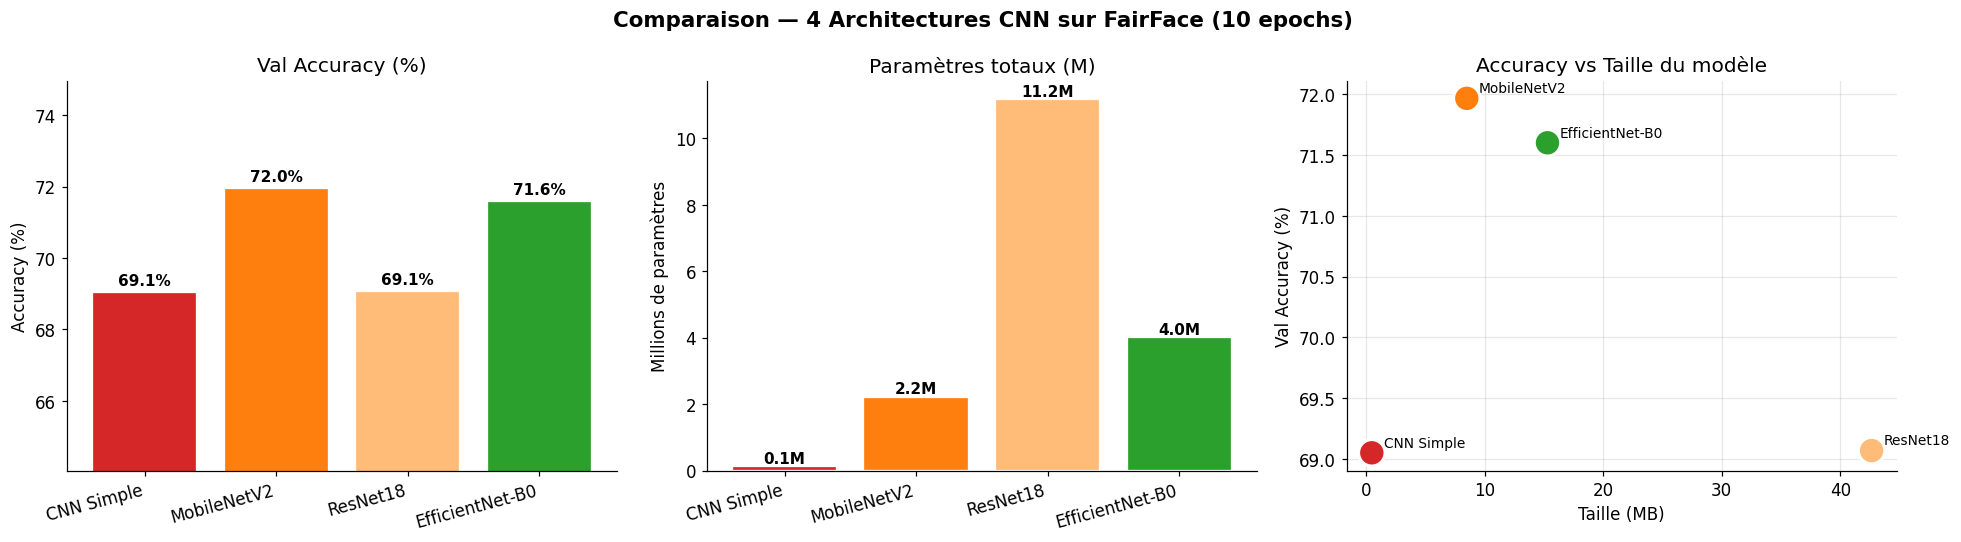

In [21]:
#Visualisation 3 graphes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Comparaison — 4 Architectures CNN sur FairFace ({EPOCHS_COMPARE} epochs)',
             fontsize=14, fontweight='bold')

names   = list(results.keys())
accs    = [r['acc']*100        for r in results.values()]
params  = [r['params']/1e6     for r in results.values()]
sizes   = [r['size_mb']        for r in results.values()]
colors  = ['#d62728', '#ff7f0e', '#ffbb78', '#2ca02c']

# Accuracy
bars = axes[0].bar(names, accs, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set(title='Val Accuracy (%)', ylabel='Accuracy (%)')
axes[0].set_ylim(max(0, min(accs)-5), min(100, max(accs)+3))
axes[0].set_xticklabels(names, rotation=15, ha='right')
for bar, v in zip(bars, accs):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Paramètres
bars = axes[1].bar(names, params, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set(title='Paramètres totaux (M)', ylabel='Millions de paramètres')
axes[1].set_xticklabels(names, rotation=15, ha='right')
for bar, v in zip(bars, params):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{v:.1f}M', ha='center', fontsize=10, fontweight='bold')

# Accuracy vs Taille
axes[2].scatter(sizes, accs, c=colors, s=300, zorder=5, edgecolors='white', linewidth=2)
for name, sz, ac in zip(names, sizes, accs):
    axes[2].annotate(name, (sz, ac), textcoords='offset points', xytext=(8, 4), fontsize=9)
axes[2].set(title='Accuracy vs Taille du modèle',
            xlabel='Taille (MB)', ylabel='Val Accuracy (%)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9 — Conclusion : Choix du Modèle Final

### Résultats de la comparaison (10 epochs, backbone gelé)

| Modèle | Params | Taille | Val Acc | Stratégie |
|---|---|---|---|---|
| CNN Simple | 127K | 0.5 MB | 69.05% | From Scratch |
| ResNet18 | 11.2M | 42.6 MB | 69.07% | Transfer Learning |
| EfficientNet-B0 | 4.0M | 15.3 MB | 71.60% | Transfer Learning |
| **MobileNetV2** | **2.2M** | **8.5 MB** | **71.96%** | **Transfer Learning** |

### Analyse

**Observation 1 — Transfer Learning >> From Scratch**

CNN Simple (69.05%) et ResNet18 (69.07%) sont au même niveau malgré
11M vs 127K paramètres. ResNet18 avec backbone gelé n'a que 512 paramètres
entraînables dans sa tête — il ne peut pas exprimer son potentiel.
Le CNN Simple plafonne faute de connaissance préalable des visages.

**Observation 2 — Plus de paramètres ≠ meilleur résultat**

ResNet18 (11.2M, 42.6 MB) < MobileNetV2 (2.2M, 8.5 MB) en accuracy.
Architecture plus lourde ≠ convergence plus rapide avec backbone gelé.

**Observation 3 — MobileNetV2 = meilleur choix pour ce projet**

MobileNetV2 obtient la **meilleure accuracy (71.96%)** avec le **moins de paramètres**
parmi les modèles Transfer Learning (2.2M) et la **plus petite taille (8.5 MB)**.

Pour un système embarqué d'aide aux malvoyants :
- Inférence temps réel → légèreté critique
- Déploiement sur mobile/edge → taille minimale
- Meilleure accuracy → sécurité de l'utilisateur

### Modèle choisi : MobileNetV2

→ Fine-tuning complet pour maximiser ses performances.



## 10 — Fine-Tuning Complet — MobileNetV2

### Problèmes à résoudre

**Problème 1 — Dataset déséquilibré**

```
Train :
  adulte        55 592  (64%)  <- dominant
  enfant        21 303  (25%)
  personne_agee  9 849  (11%)  <- minoritaire
```

**Solution (v1 — première approche) — WeightedRandomSampler + Loss pondérée**

```python
# Double correction : Sampler rééquilibre le tirage ET loss pondère les erreurs
sampler = WeightedRandomSampler(weights, num_samples, replacement=True)
criterion = CrossEntropyLoss(weight=class_weights)
```

> **Attention — double correction**
> Cette approche semble logique mais elle sur-corrige le déséquilibre :
> le modèle voit autant d'adultes que de personne_agee (Sampler)
> ET pénalise encore plus les erreurs sur personne_agee (loss)
> → résultat attendu : adulte recall très dégradé

**Problème 2 — Fine-tuning sans détruire ImageNet**

Dual learning rates :
```
Backbone features  → lr = 0.00001
Classifier head    → lr = 0.0001
```

**Problème 3 — Surapprentissage**

- `EarlyStopping` patience=5
- `weight_decay=1e-4`
- `label_smoothing=0.1`
- `Dropout(0.3)` dans la tête
- `ReduceLROnPlateau` scheduler


In [1]:
import math
from collections import Counter

# Distribution des classes train
labels_train = [CLASS_TO_IDX[c] for c in train_df["classe"]]
class_counts  = Counter(labels_train)

print("Distribution originale train :")
for cls, name in IDX_TO_CLASS.items():
    pct = class_counts[cls] / len(labels_train) * 100
    print(f"  {name:<15} : {class_counts[cls]:,} images ({pct:.1f}%)")

print()
print("Dataset déséquilibré — adulte dominant 64%")
print("Approche v1 : WeightedRandomSampler + Loss pondérée (double correction)")


NameError: name 'train_df' is not defined

In [ ]:
# ── WeightedRandomSampler — rééquilibre le tirage des batches ────────────────
# Chaque classe tirée avec probabilité inversement proportionnelle à sa fréquence
# → adulte et personne_agee apparaissent autant dans chaque batch

sample_weights = torch.tensor(
    [1.0 / class_counts[CLASS_TO_IDX[c]] for c in train_df["classe"]],
    dtype=torch.float
)

sampler_ft = torch.utils.data.WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

# ── Loss pondérée — pénalise aussi les erreurs sur les classes minoritaires ───
weights_tensor = torch.tensor(
    [1.0 / math.sqrt(class_counts[cls]) for cls in range(NUM_CLASSES)],
    dtype=torch.float
)
weights_tensor = weights_tensor / weights_tensor.sum() * NUM_CLASSES
weights_tensor = weights_tensor.to(device)

criterion_weighted = nn.CrossEntropyLoss(
    weight          = weights_tensor,
    label_smoothing = 0.1
)

print("Poids dans la loss CrossEntropy :")
for cls, name in IDX_TO_CLASS.items():
    print(f"  {name:<15} : {weights_tensor[cls].item():.4f}")

# DataLoader avec Sampler (pas de shuffle — incompatible avec Sampler)
train_loader_ft = DataLoader(
    FairFaceDataset(train_df, train_transform),
    batch_size  = 32,
    sampler     = sampler_ft,   # ← WeightedRandomSampler actif
    num_workers = 2,
    pin_memory  = True
)

print("\nDataLoader configuré avec WeightedRandomSampler")
print("Double correction active : Sampler + Loss pondérée")
print("⚠️  Risque de sur-correction — adulte recall peut chuter")


Poids dans la loss CrossEntropy :
  adulte          : 0.3242
  enfant          : 0.8460
  personne_agée   : 1.8298


In [ ]:
# ── Construire MobileNetV2 avec nouvelle tête améliorée ──────────────────────
# On repart du modèle pré-entraîné ImageNet (fresh start du fine-tuning)
# pour éviter de partir d'un état sous-optimal après la comparaison

mobilenet_ft = models.mobilenet_v2(weights='IMAGENET1K_V1')

# Dégeler TOUTES les couches dès le départ (fine-tuning complet)
for param in mobilenet_ft.parameters():
    param.requires_grad = True

# Remplacer la tête avec Dropout pour réduire le surapprentissage
# MobileNetV2 : classifier = [Dropout(0.2), Linear(1280, 1000)]
mobilenet_ft.classifier = nn.Sequential(
    nn.Dropout(p=0.3),              # plus fort que le défaut 0.2
    nn.Linear(1280, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.2),
    nn.Linear(256, NUM_CLASSES)
)

mobilenet_ft = mobilenet_ft.to(device)

n_total     = sum(p.numel() for p in mobilenet_ft.parameters())
n_trainable = sum(p.numel() for p in mobilenet_ft.parameters() if p.requires_grad)
size_mb     = sum(p.numel() * p.element_size() for p in mobilenet_ft.parameters()) / (1024**2)

print(f"MobileNetV2 Fine-Tuning")
print(f"  Paramètres totaux      : {n_total:,}")
print(f"  Paramètres entraînables: {n_trainable:,}")
print(f"  Taille                 : {size_mb:.1f} MB")

MobileNetV2 Fine-Tuning
  Paramètres totaux      : 2,552,579
  Paramètres entraînables: 2,552,579
  Taille                 : 9.7 MB


In [ ]:
# ── Dual learning rates ───────────────────────────────────────────────────────
optimizer_ft = optim.Adam([
    {'params': mobilenet_ft.features.parameters(),   'lr': 0.00001},
    {'params': mobilenet_ft.classifier.parameters(), 'lr': 0.0001},
], weight_decay=1e-4)

# Scheduler — réduire lr si val_loss stagne
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode    = 'min',   # surveille val_loss
    factor  = 0.5,     # divise lr par 2
    patience= 3,       # attend 3 epochs sans amélioration
)

print("Optimiseur configuré")
print("   Backbone features  : lr = 0.00001")
print("   Classifier head    : lr = 0.0001")
print("   Scheduler          : ReduceLROnPlateau (factor=0.5, patience=3)")

Optimiseur configuré
   Backbone features  : lr = 0.00001
   Classifier head    : lr = 0.0001
   Scheduler          : ReduceLROnPlateau (factor=0.5, patience=3)


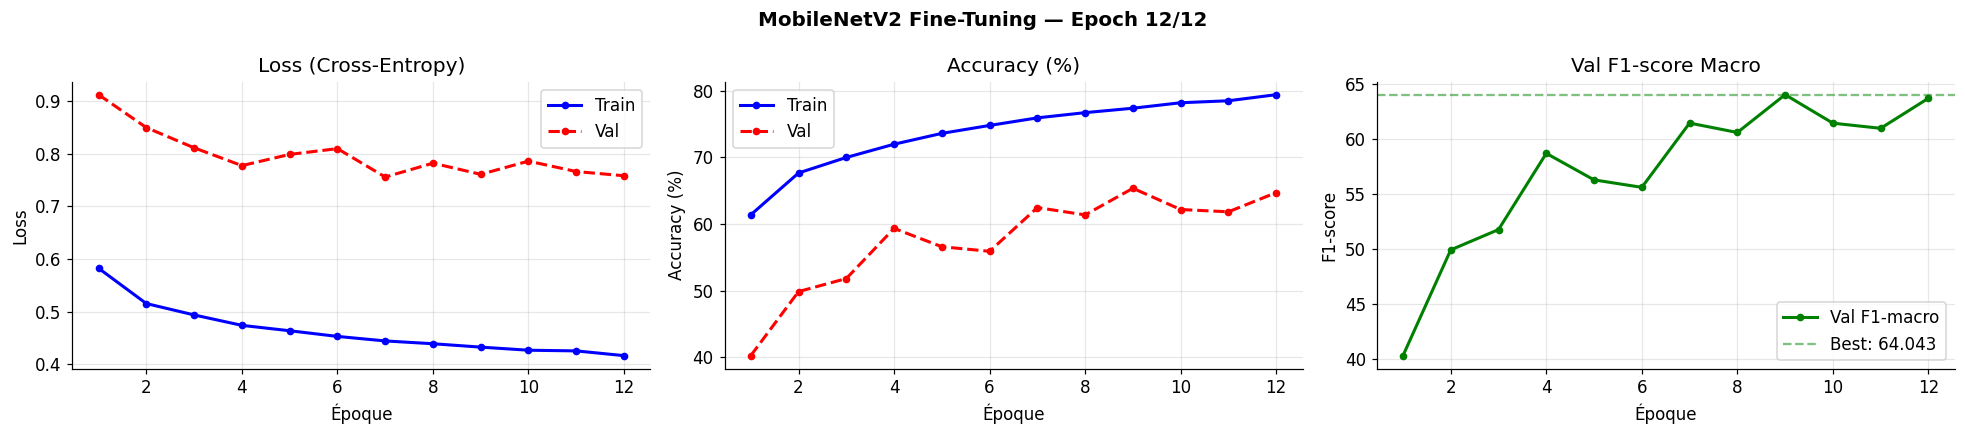


  Fine-Tuning Terminé
  Meilleur Val F1-macro : 64.04%
  Meilleur Val Accuracy : 65.36%


In [ ]:
# ── Boucle d'entraînement fine-tuning ────────────────────────────────────────
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time, os

NUM_EPOCHS = 20

# Historique
history = {
    'train_loss': [], 'val_loss'  : [],
    'train_acc' : [], 'val_acc'   : [],
    'val_f1'    : []   # F1 macro — crucial pour dataset déséquilibré
}

best_val_f1   = 0.0
best_val_acc  = 0.0
save_path     = "/kaggle/working/mobilenetv2_fairface.pth"

def plot_history(history, epoch, num_epochs):
    """Trace les courbes en temps réel — style TP cours."""
    clear_output(wait=True)
    n   = len(history['val_loss'])
    eps = range(1, n + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f'MobileNetV2 Fine-Tuning — Epoch {epoch}/{num_epochs}',
                 fontsize=13, fontweight='bold')

    # Loss
    axes[0].plot(eps, history['train_loss'], 'b-o', lw=2, ms=4, label='Train')
    axes[0].plot(eps, history['val_loss'],   'r--o', lw=2, ms=4, label='Val')
    axes[0].set(title='Loss (Cross-Entropy)', xlabel='Époque', ylabel='Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(eps, history['train_acc'], 'b-o', lw=2, ms=4, label='Train')
    axes[1].plot(eps, history['val_acc'],   'r--o', lw=2, ms=4, label='Val')
    axes[1].set(title='Accuracy (%)', xlabel='Époque', ylabel='Accuracy (%)')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # F1 Macro — métrique principale pour déséquilibre
    axes[2].plot(eps, history['val_f1'], 'g-o', lw=2, ms=4, label='Val F1-macro')
    axes[2].axhline(max(history['val_f1']), color='green', ls='--', alpha=0.5,
                    label=f"Best: {max(history['val_f1']):.3f}")
    axes[2].set(title='Val F1-score Macro', xlabel='Époque', ylabel='F1-score')
    axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print(f"Début entraînement — {NUM_EPOCHS} epochs")
print(f"Correction desequilibre   : Loss ponderee (racine carree)")
print(f"Loss pondérée par classe  : CrossEntropyLoss(weight=...)")
print("=" * 55)

patience_counter = 0
PATIENCE = 5

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # ── Phase TRAIN ──────────────────────────────────────────
    mobilenet_ft.train()
    train_loss    = 0.0
    train_correct = 0
    train_total   = 0

    for images, labels in train_loader_ft:
        images, labels = images.to(device), labels.to(device)

        optimizer_ft.zero_grad()
        outputs = mobilenet_ft(images)
        loss    = criterion_weighted(outputs, labels)
        loss.backward()
        optimizer_ft.step()

        train_loss    += loss.item()
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)

    # ── Phase VAL ────────────────────────────────────────────
    mobilenet_ft.eval()
    val_loss    = 0.0
    val_correct = 0
    val_total   = 0
    all_preds   = []
    all_labels  = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs  = mobilenet_ft(images)
            loss     = criterion_weighted(outputs, labels)
            val_loss += loss.item()
            preds    = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # ── Métriques ─────────────────────────────────────────────
    t_loss = train_loss / len(train_loader_ft)
    v_loss = val_loss   / len(val_loader)
    t_acc  = train_correct / train_total * 100
    v_acc  = val_correct   / val_total   * 100
    v_f1   = f1_score(all_labels, all_preds, average='macro') * 100

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    history['val_f1'].append(v_f1)

    # Scheduler step sur val_loss
    scheduler.step(v_loss)

    # Sauvegarde meilleur modèle sur F1 macro (pas accuracy)
    # F1 macro est plus fiable sur dataset déséquilibré
    if v_f1 > best_val_f1:
        best_val_f1  = v_f1
        best_val_acc = v_acc
        torch.save(mobilenet_ft.state_dict(), save_path)
        saved_marker = "  sauvegardé"
        patience_counter = 0
    else:
        saved_marker = ""
        patience_counter += 1

    elapsed = time.time() - t0
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {t_loss:.3f} Acc: {t_acc:.1f}% | "
          f"Val Loss: {v_loss:.3f} Acc: {v_acc:.1f}% F1: {v_f1:.1f}%"
          f"{saved_marker} ({elapsed:.0f}s)")

    plot_history(history, epoch, NUM_EPOCHS)

    # Early stopping sur patience
    if patience_counter >= PATIENCE:
        print(f"\n  Early stopping déclenché à l'epoch {epoch}")
        break

print(f"\n{'='*55}")
print(f"  Fine-Tuning Terminé")
print(f"  Meilleur Val F1-macro : {best_val_f1:.2f}%")
print(f"  Meilleur Val Accuracy : {best_val_acc:.2f}%")
print(f"{'='*55}")


In [ ]:
# ── Vérification sauvegarde ──────────────────────────────────────────────────
size_mb = os.path.getsize(save_path) / (1024**2)
print(f" Modèle sauvegardé : {save_path}")
print(f"   Taille            : {size_mb:.1f} MB")
print()
print("Pour charger ce modèle :")
print("""
from torchvision import models
import torch.nn as nn

model = models.mobilenet_v2()
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(1280, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.2),
    nn.Linear(256, 3)
)
model.load_state_dict(torch.load('mobilenetv2_fairface.pth'))
model.eval()
""")


 Modèle sauvegardé : /kaggle/working/mobilenetv2_fairface.pth
   Taille            : 10.0 MB

Pour charger ce modèle :

from torchvision import models
import torch.nn as nn

model = models.mobilenet_v2()
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(1280, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.2),
    nn.Linear(256, 3)
)
model.load_state_dict(torch.load('mobilenetv2_fairface.pth'))
model.eval()



## 11 — Évaluation Finale

### Charger le meilleur modèle sauvegardé

On charge le checkpoint sauvegardé sur le **meilleur F1-macro**
(pas la dernière epoch) pour l'évaluation finale.

In [32]:
# ── Charger le meilleur checkpoint ───────────────────────────────────────────
mobilenet_ft.load_state_dict(torch.load(save_path, map_location=device))
mobilenet_ft.eval()
print(f" Meilleur modèle chargé depuis {save_path}")
print(f"   Val F1-macro   : {best_val_f1:.2f}%")
print(f"   Val Accuracy   : {best_val_acc:.2f}%")

 Meilleur modèle chargé depuis /kaggle/working/mobilenetv2_fairface.pth
   Val F1-macro   : 64.04%
   Val Accuracy   : 65.36%


In [33]:
# ── Collecter toutes les prédictions sur val ─────────────────────────────────
all_preds_final  = []
all_labels_final = []
all_probs_final  = []

with torch.no_grad():
    for images, labels in val_loader:
        images   = images.to(device)
        logits   = mobilenet_ft(images)
        probs    = torch.softmax(logits, dim=1).cpu()
        preds    = torch.argmax(logits, dim=1).cpu()
        all_preds_final.extend(preds.numpy())
        all_labels_final.extend(labels.numpy())
        all_probs_final.extend(probs.numpy())

all_preds_final  = np.array(all_preds_final)
all_labels_final = np.array(all_labels_final)
all_probs_final  = np.array(all_probs_final)

final_acc = (all_preds_final == all_labels_final).mean() * 100
final_f1  = f1_score(all_labels_final, all_preds_final, average='macro') * 100

print(f"Val Accuracy finale : {final_acc:.2f}%")
print(f"Val F1-macro finale : {final_f1:.2f}%")


Val Accuracy finale : 65.36%
Val F1-macro finale : 64.04%


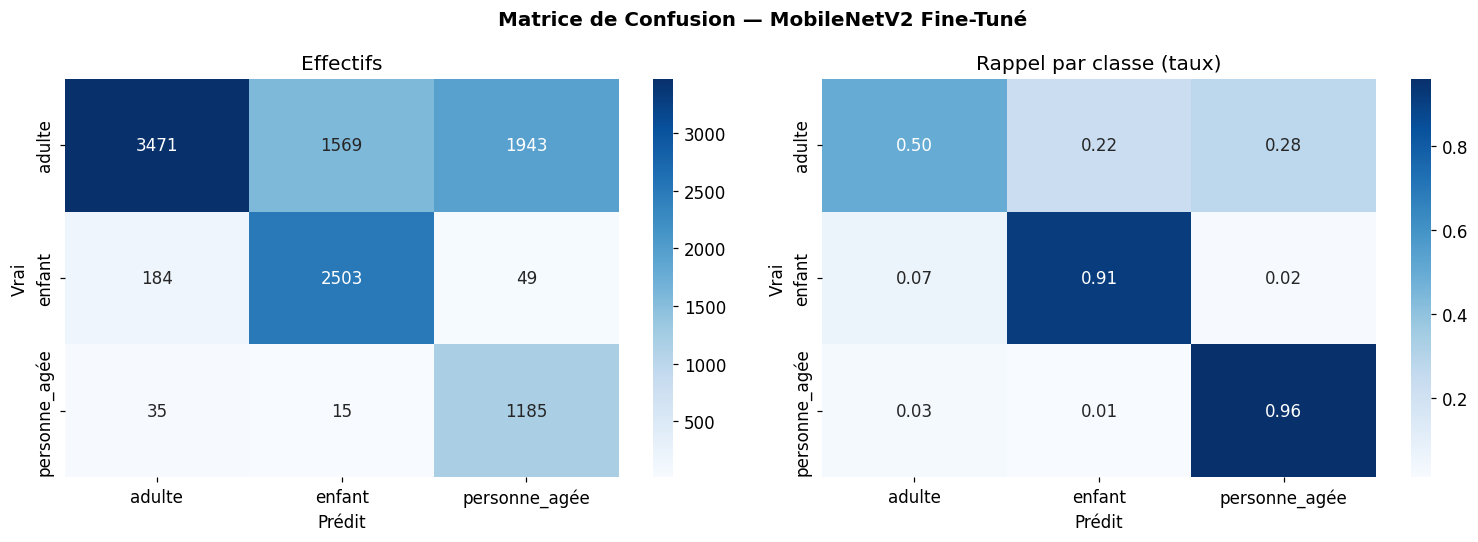

In [34]:
# ── Matrice de confusion ─────────────────────────────────────────────────────
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cm     = confusion_matrix(all_labels_final, all_preds_final)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Matrice de Confusion — MobileNetV2 Fine-Tuné', fontsize=13, fontweight='bold')

sns.heatmap(cm,     annot=True, fmt='d',    cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set(title='Effectifs', xlabel='Prédit', ylabel='Vrai')

sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set(title='Rappel par classe (taux)', xlabel='Prédit', ylabel='Vrai')

plt.tight_layout()
plt.show()

In [35]:
# ── Classification Report complet ────────────────────────────────────────────
print("Classification Report — MobileNetV2 Fine-Tuné")
print("=" * 60)
print(classification_report(
    all_labels_final, all_preds_final,
    target_names=CLASS_NAMES, digits=3
))
print()
print(f"  Val Accuracy : {final_acc:.2f}%")
print(f"  Val F1-macro : {final_f1:.2f}%")

Classification Report — MobileNetV2 Fine-Tuné
               precision    recall  f1-score   support

       adulte      0.941     0.497     0.650      6983
       enfant      0.612     0.915     0.734      2736
personne_agée      0.373     0.960     0.537      1235

     accuracy                          0.654     10954
    macro avg      0.642     0.790     0.640     10954
 weighted avg      0.795     0.654     0.658     10954


  Val Accuracy : 65.36%
  Val F1-macro : 64.04%


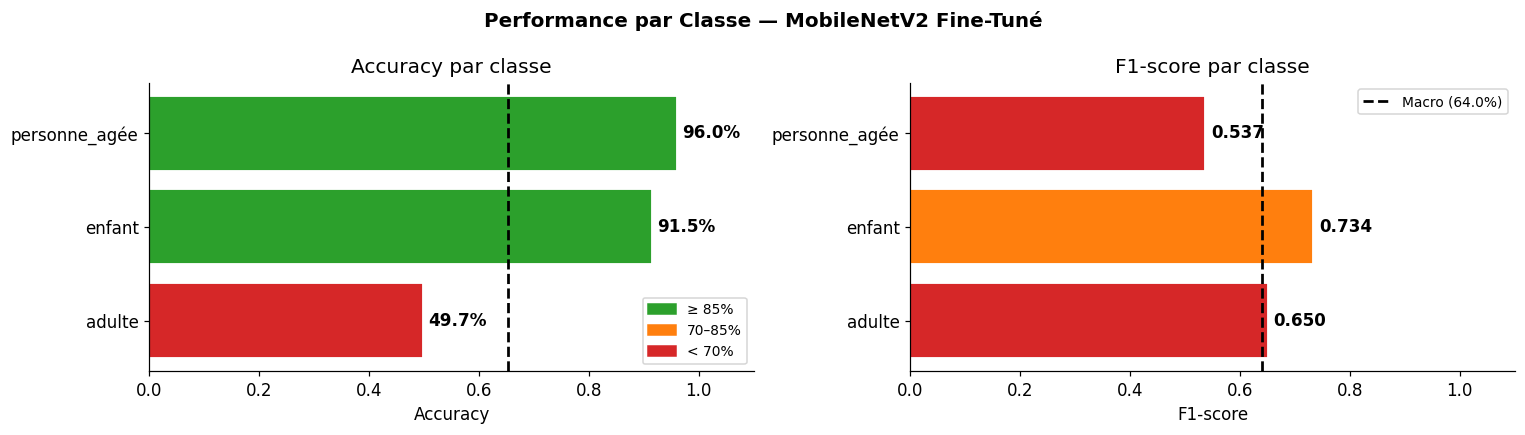


 Le F1-score est la métrique principale pour ce dataset déséquilibré.
   Un F1 élevé sur personne_agee confirme que le modèle ne prédit pas
   uniquement 'adulte' par défaut.


In [36]:
# ── Accuracy & F1 par classe ─────────────────────────────────────────────────
import matplotlib.patches as mpatches
from sklearn.metrics import f1_score

per_class_acc = cm_pct.diagonal()
per_class_f1  = f1_score(all_labels_final, all_preds_final, average=None)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Performance par Classe — MobileNetV2 Fine-Tuné', fontsize=13, fontweight='bold')

# Accuracy par classe
colors_acc = ['#2ca02c' if a >= 0.85 else '#ff7f0e' if a >= 0.70 else '#d62728'
              for a in per_class_acc]
bars = axes[0].barh(CLASS_NAMES, per_class_acc, color=colors_acc,
                    edgecolor='white', linewidth=1.2)
axes[0].axvline(final_acc/100, color='black', ls='--', lw=1.8,
                label=f'Moyenne ({final_acc:.1f}%)')
axes[0].set(xlabel='Accuracy', title='Accuracy par classe', xlim=(0, 1.1))
for bar, v in zip(bars, per_class_acc):
    axes[0].text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                 f'{v*100:.1f}%', va='center', fontsize=11, fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#2ca02c', label='≥ 85%'),
    mpatches.Patch(color='#ff7f0e', label='70–85%'),
    mpatches.Patch(color='#d62728', label='< 70%'),
]
axes[0].legend(handles=legend_patches, loc='lower right', fontsize=9)

# F1 par classe
colors_f1 = ['#2ca02c' if f >= 0.85 else '#ff7f0e' if f >= 0.70 else '#d62728'
             for f in per_class_f1]
bars2 = axes[1].barh(CLASS_NAMES, per_class_f1, color=colors_f1,
                     edgecolor='white', linewidth=1.2)
axes[1].axvline(final_f1/100, color='black', ls='--', lw=1.8,
                label=f'Macro ({final_f1:.1f}%)')
axes[1].set(xlabel='F1-score', title='F1-score par classe', xlim=(0, 1.1))
for bar, v in zip(bars2, per_class_f1):
    axes[1].text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\n Le F1-score est la métrique principale pour ce dataset déséquilibré.")
print("   Un F1 élevé sur personne_agee confirme que le modèle ne prédit pas")
print("   uniquement 'adulte' par défaut.")

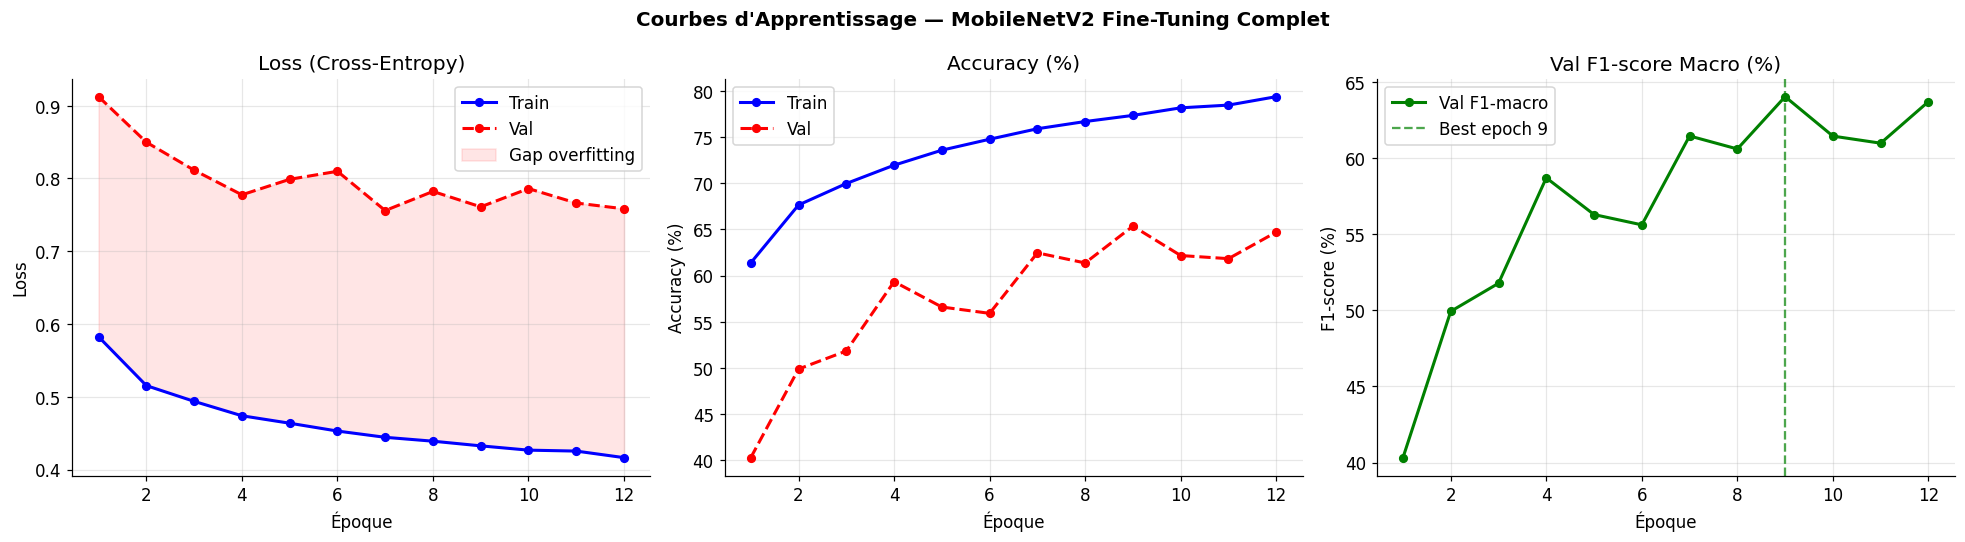

Gap Train/Val accuracy : 14.7%
Surapprentissage — envisager plus de Dropout ou de données.


In [37]:
# ── Courbe d'apprentissage finale + analyse surapprentissage ─────────────────
n   = len(history['val_loss'])
eps = range(1, n+1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Courbes d'Apprentissage — MobileNetV2 Fine-Tuning Complet",
             fontsize=13, fontweight='bold')

# Loss
axes[0].plot(eps, history['train_loss'], 'b-o', lw=2, ms=5, label='Train')
axes[0].plot(eps, history['val_loss'],   'r--o', lw=2, ms=5, label='Val')
axes[0].fill_between(eps,
    history['train_loss'], history['val_loss'],
    alpha=0.1, color='red', label='Gap overfitting'
)
axes[0].set(title='Loss (Cross-Entropy)', xlabel='Époque', ylabel='Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(eps, history['train_acc'], 'b-o', lw=2, ms=5, label='Train')
axes[1].plot(eps, history['val_acc'],   'r--o', lw=2, ms=5, label='Val')
axes[1].set(title='Accuracy (%)', xlabel='Époque', ylabel='Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# F1 Macro
axes[2].plot(eps, history['val_f1'], 'g-o', lw=2, ms=5, label='Val F1-macro')
best_ep = history['val_f1'].index(max(history['val_f1'])) + 1
axes[2].axvline(best_ep, color='green', ls='--', alpha=0.7,
                label=f'Best epoch {best_ep}')
axes[2].set(title='Val F1-score Macro (%)', xlabel='Époque', ylabel='F1-score (%)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interprétation automatique
gap = history['train_acc'][-1] - history['val_acc'][-1]
print(f"Gap Train/Val accuracy : {gap:.1f}%")
if   gap < 5:  print("Pas de surapprentissage — courbes train/val proches.")
elif gap < 10: print("Léger surapprentissage — gap acceptable pour FairFace (dataset difficile).")
else:          print("Surapprentissage — envisager plus de Dropout ou de données.")


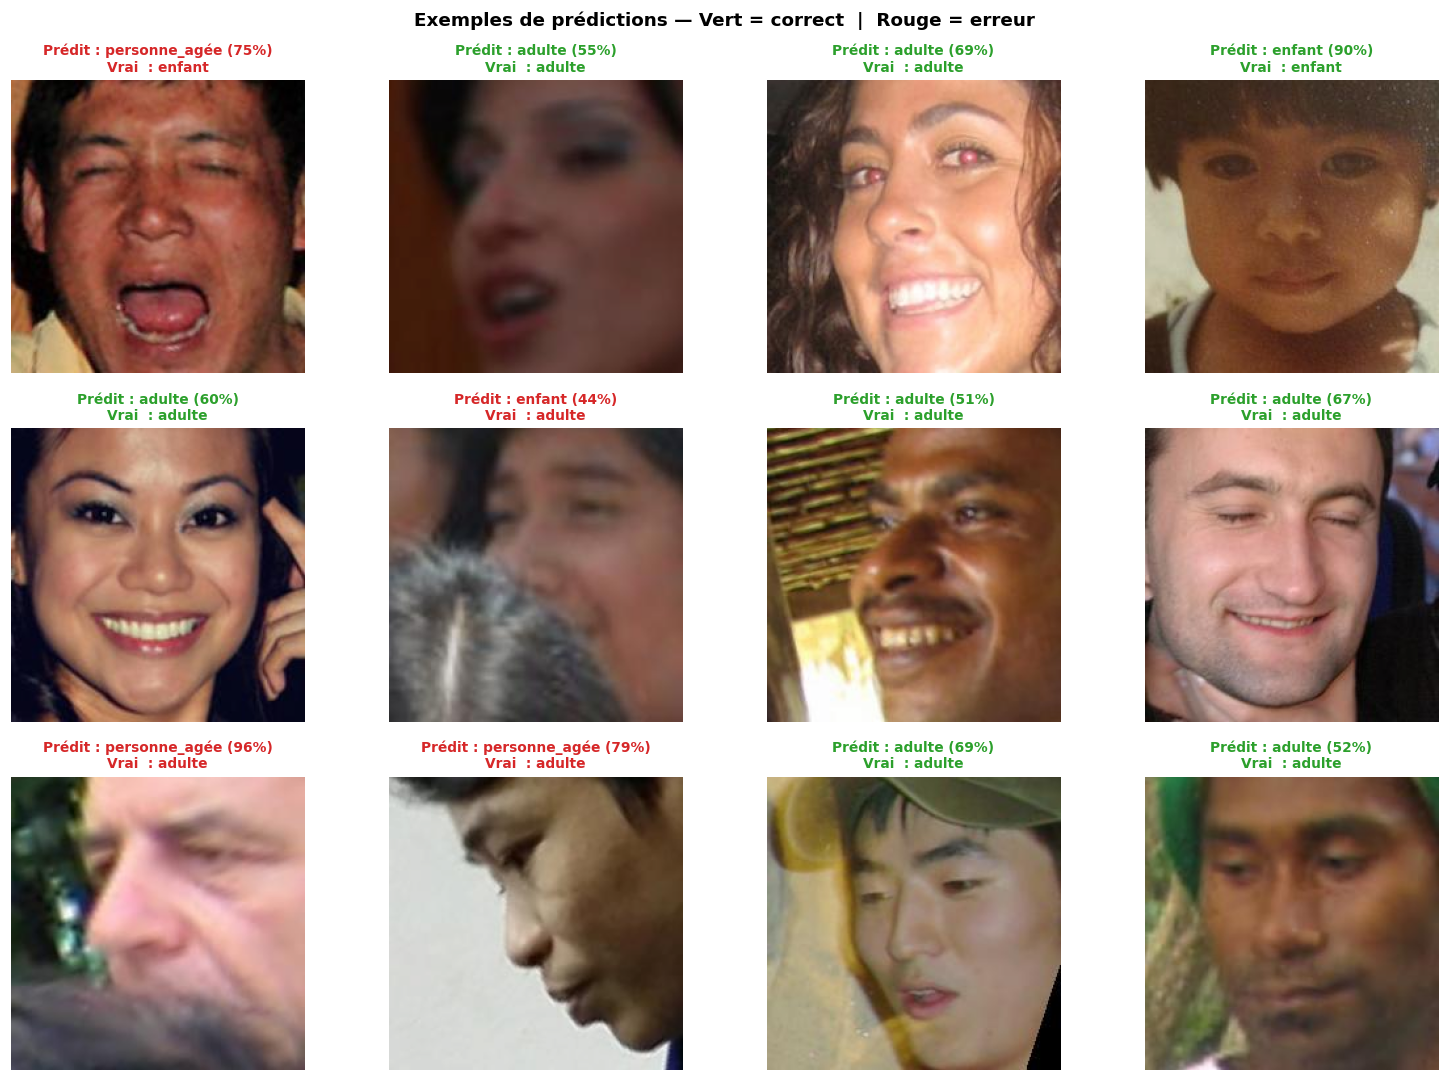

In [38]:
# ── Exemples visuels — correct vs erreur ─────────────────────────────────────
sample_df = val_df.sample(12, random_state=42).reset_index(drop=True)
sample_ds = FairFaceDataset(sample_df, val_transform)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle("Exemples de prédictions — Vert = correct  |  Rouge = erreur",
             fontsize=12, fontweight='bold')

mobilenet_ft.eval()
with torch.no_grad():
    for i, (image, label) in enumerate(sample_ds):
        logits = mobilenet_ft(image.unsqueeze(0).to(device))
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred   = int(np.argmax(probs))
        conf   = probs[pred] * 100

        img_show = image.permute(1, 2, 0).numpy()
        img_show = img_show * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
        img_show = np.clip(img_show, 0, 1)

        color = '#2ca02c' if pred == label else '#d62728'
        axes.flat[i].imshow(img_show)
        axes.flat[i].axis('off')
        axes.flat[i].set_title(
            f"Prédit : {IDX_TO_CLASS[pred]} ({conf:.0f}%)\nVrai  : {IDX_TO_CLASS[label]}",
            color=color, fontsize=9, fontweight='bold'
        )

plt.tight_layout()
plt.show()

In [39]:
# ── Top confusions ───────────────────────────────────────────────────────────
from collections import Counter

error_mask = all_preds_final != all_labels_final
error_true = all_labels_final[error_mask]
error_pred = all_preds_final[error_mask]
pairs      = Counter(zip(error_true, error_pred))

print(f"Taux d'erreur global : {error_mask.mean()*100:.1f}%")
print()
print("Top confusions (vrai → prédit) :")
print("─" * 45)
for (true_c, pred_c), count in pairs.most_common(6):
    pct = count / error_mask.sum() * 100
    print(f"  {IDX_TO_CLASS[true_c]:<15} → {IDX_TO_CLASS[pred_c]:<15} : {count:,} fois ({pct:.1f}% des erreurs)")

Taux d'erreur global : 34.6%

Top confusions (vrai → prédit) :
─────────────────────────────────────────────
  adulte          → personne_agée   : 1,943 fois (51.2% des erreurs)
  adulte          → enfant          : 1,569 fois (41.3% des erreurs)
  enfant          → adulte          : 184 fois (4.8% des erreurs)
  enfant          → personne_agée   : 49 fois (1.3% des erreurs)
  personne_agée   → adulte          : 35 fois (0.9% des erreurs)
  personne_agée   → enfant          : 15 fois (0.4% des erreurs)


## 12 — Résumé Final (v1 — Brouillon)

### Résultats complets — approche double correction

| Étape | Modèle | Val Acc | Val F1 | Remarque |
|---|---|---|---|---|
| Baseline | CNN Simple (from scratch) | 69.05% | faible | référence |
| Comparaison | ResNet18 | 69.07% | moyen | backbone gelé → limité |
| Comparaison | EfficientNet-B0 | 71.60% | bon | compound scaling |
| Comparaison | MobileNetV2 | 71.96% | bon | léger + rapide → winner |
| **Fine-Tuning v1** | **MobileNetV2** | **65.36%** | ** 64.04%** | double correction |

### Problème observé — Double correction trop agressive

```
Approche v1 : WeightedRandomSampler + Loss pondérée
  → adulte recall chute à ~49%
  → le modèle sur-prédit personne_agee et enfant
  → F1-macro plafonné à  64.04%

Cause : Sampler rééquilibre déjà les batches
        + Loss pénalise encore les classes minoritaires
        = adulte vu comme "facile" et ignoré
```

→ **Voir `3_v2_Model_Comparison.ipynb` pour la version corrigée et finale.**

### Intégration dans Object-Finder

```
Image camera
      |
YOLOv8 → détecte person + bounding box
      |
Crop 224x224
      |
MobileNetV2 Fine-Tuné (v2 — Loss pondérée seule)
      |
adulte / enfant / personne_agee
      |
Niveau de danger + Alerte vocale
```
